In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp, spectrogram, windows
from scipy.fft import rfft, rfftfreq

In [5]:
# ==========================================
# 1. PARAMETERS (Easily Adjustable)
# ==========================================
f_start = 1.0       # Starting frequency (Hz)
f_end = 500.0       # Ending frequency (Hz)
fs = 20000           # Sampling frequency (Hz)
duration = 10.0     # Duration of the sweep (seconds)
tukey_alpha = 0.05  # Shape parameter for Tukey window (fades first/last 5%)
buffer_duration_start = 1.0  # Buffer time (seconds) at start to avoid shaker transients (seconds)
buffer_duration_end = 1.5  # Buffer time (seconds) at end to avoid shaker transients (seconds)

# ==========================================
# 2. GENERATE SIGNAL
# ==========================================
# Create time array
t = np.arange(0, duration, 1/fs)

# Generate Logarithmic Sweep (gives more time to lower frequencies)
signal = chirp(t, f0=f_start, f1=f_end, t1=duration, method='logarithmic')

# Apply Tukey window to smooth start and end (avoids shaker transients)
window = windows.tukey(len(signal), alpha=tukey_alpha)
signal = signal * window

# Normalize to ensure max amplitude is exactly bounded between -1 and 1
signal = signal / np.max(np.abs(signal))

# --- Add Buffers ---
buffer_samples_start = int(buffer_duration_start * fs)
buffer_samples_end = int(buffer_duration_end * fs)
zeros_pad_start = np.zeros(buffer_samples_start)
zeros_pad_end = np.zeros(buffer_samples_end)

# Concatenate: [0s] + [signal] + [0s]
signal = np.concatenate([zeros_pad_start, signal, zeros_pad_end + zeros_pad_end])

# Update the time array to match the new length
t = np.arange(0, len(signal)) / fs

C:\Users\ocornelius\AppData\Local\Temp\ipykernel_24676\62554234.py:25: RuntimeWarning: divide by zero encountered in log10
  im = axs[2].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis', vmin=-150, vmax=-10)


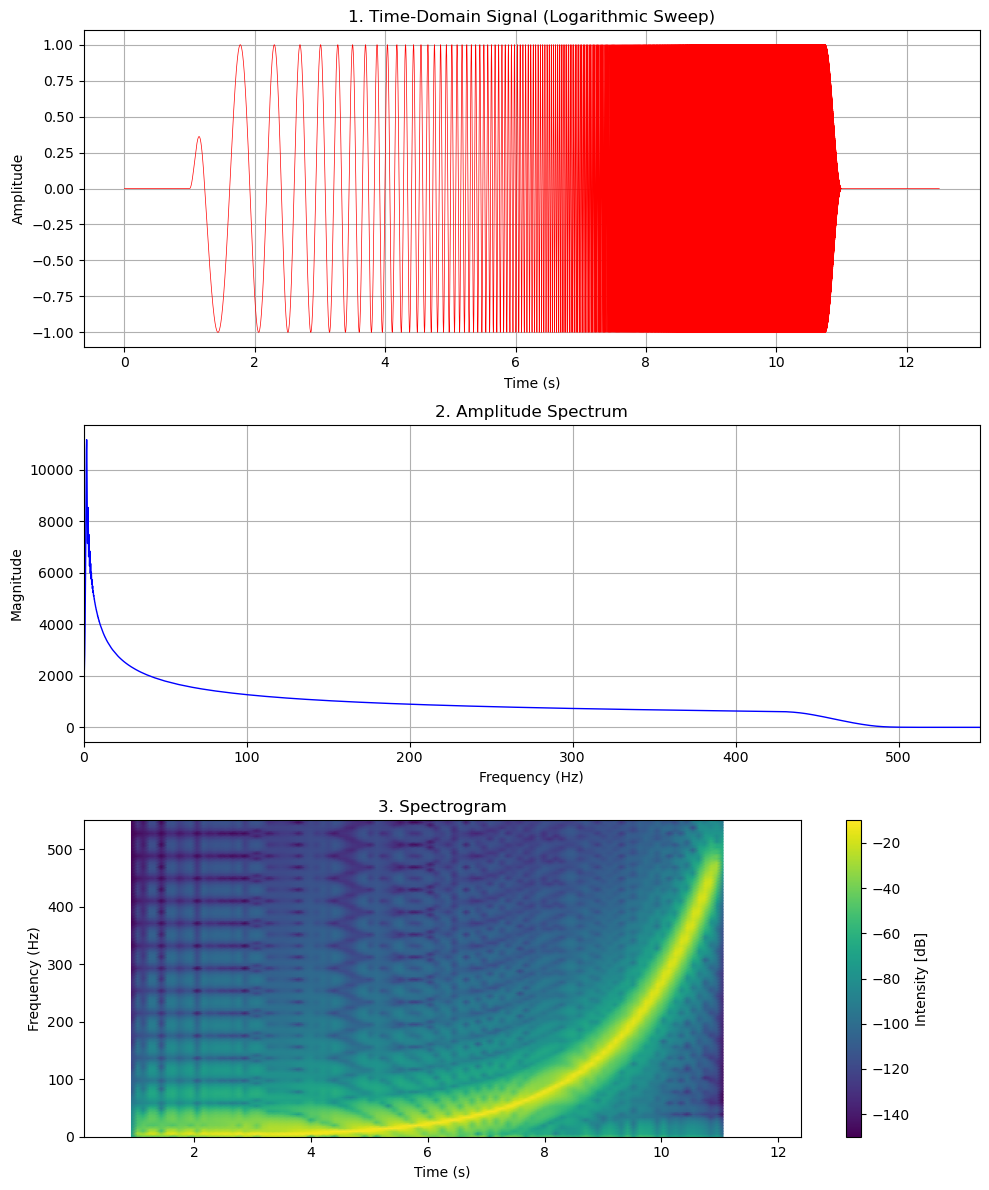

In [6]:
# ==========================================
# 3. PLOTTING
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Plot 1: Time Signal
axs[0].plot(t, signal, 'r', lw=0.5)
axs[0].set_title('1. Time-Domain Signal (Logarithmic Sweep)')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# Plot 2: Amplitude Spectrum
yf = rfft(signal)
xf = rfftfreq(len(signal), 1/fs)
axs[1].plot(xf, np.abs(yf), 'b', lw=1)
axs[1].set_title('2. Amplitude Spectrum')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Magnitude')
axs[1].set_xlim(0, f_end + 50) # zoom slightly past f_end
axs[1].grid(True)

# Plot 3: Spectrogram
f_spec, t_spec, Sxx = spectrogram(signal, fs, nperseg=4096, noverlap=2048)
im = axs[2].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis', vmin=-150, vmax=-10)
axs[2].set_title('3. Spectrogram')
axs[2].set_ylabel('Frequency (Hz)')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylim(0, f_end + 50)
fig.colorbar(im, ax=axs[2], label='Intensity [dB]')

plt.tight_layout()
plt.show()

In [34]:
# ==========================================
# 4. EXPORT TO TXT FILE
# ==========================================
output_filename = f'SweepLog_{f_start}-{f_end}Hz_{len(signal)}nt_fs{fs}Hz.txt'

with open(output_filename, 'w') as f:
    f.write('ArbWave= \n')
    for val in signal:
        f.write(f'{val:.6f} \n')
        
print(f'Successfully saved to {output_filename}')

Successfully saved to SweepLog_1.0-500.0Hz_250000nt_fs20000Hz.txt


In [7]:
# ==========================================
# LINEARITY INVESTIGATION — PARAMETERS
# ==========================================
frequencies = [5, 20, 50, 100, 150, 200, 300, 400]  # Hz — frequencies to investigate
fs_lin = 20000         # Sampling frequency (Hz)
buffer_duration = 1.0  # Silent gap before first signal and between each segment (s)
segment_duration = 3.5 # Duration of each mono-frequency segment (s)
fade_duration = 0.5    # Fade-down duration at the end of each segment (s)

end_duration = 3.0

# ==========================================
# GENERATE LINEARITY SIGNAL
# ==========================================
segments = []


# Leading silence
segments.append(np.zeros(int(buffer_duration * fs_lin)))

for freq in frequencies:
    t_seg = np.arange(0, segment_duration, 1 / fs_lin)
    n_fade = int(fade_duration * fs_lin)
    n_ramp = len(t_seg) - n_fade
    # Linear ramp 0 → 1, then short linear fade 1 → 0
    amplitude_envelope = np.concatenate([np.linspace(0, 1, n_ramp),
                                         np.linspace(1, 0, n_fade)])
    seg = amplitude_envelope * np.sin(2 * np.pi * freq * t_seg)
    segments.append(seg)
    segments.append(np.zeros(int(buffer_duration * fs_lin)))     # 1 s gap after each segment

end_buffer = np.zeros(int(end_duration*fs_lin))

lin_signal = np.concatenate(segments)

lin_signal = np.concatenate([lin_signal, end_buffer])

t_lin = np.arange(len(lin_signal)) / fs_lin

print(f"Frequencies : {frequencies} Hz")
print(f"Total duration: {len(lin_signal)/fs_lin:.1f} s  ({len(lin_signal)} samples)")

Frequencies : [5, 20, 50, 100, 150, 200, 300, 400] Hz
Total duration: 40.0 s  (800000 samples)


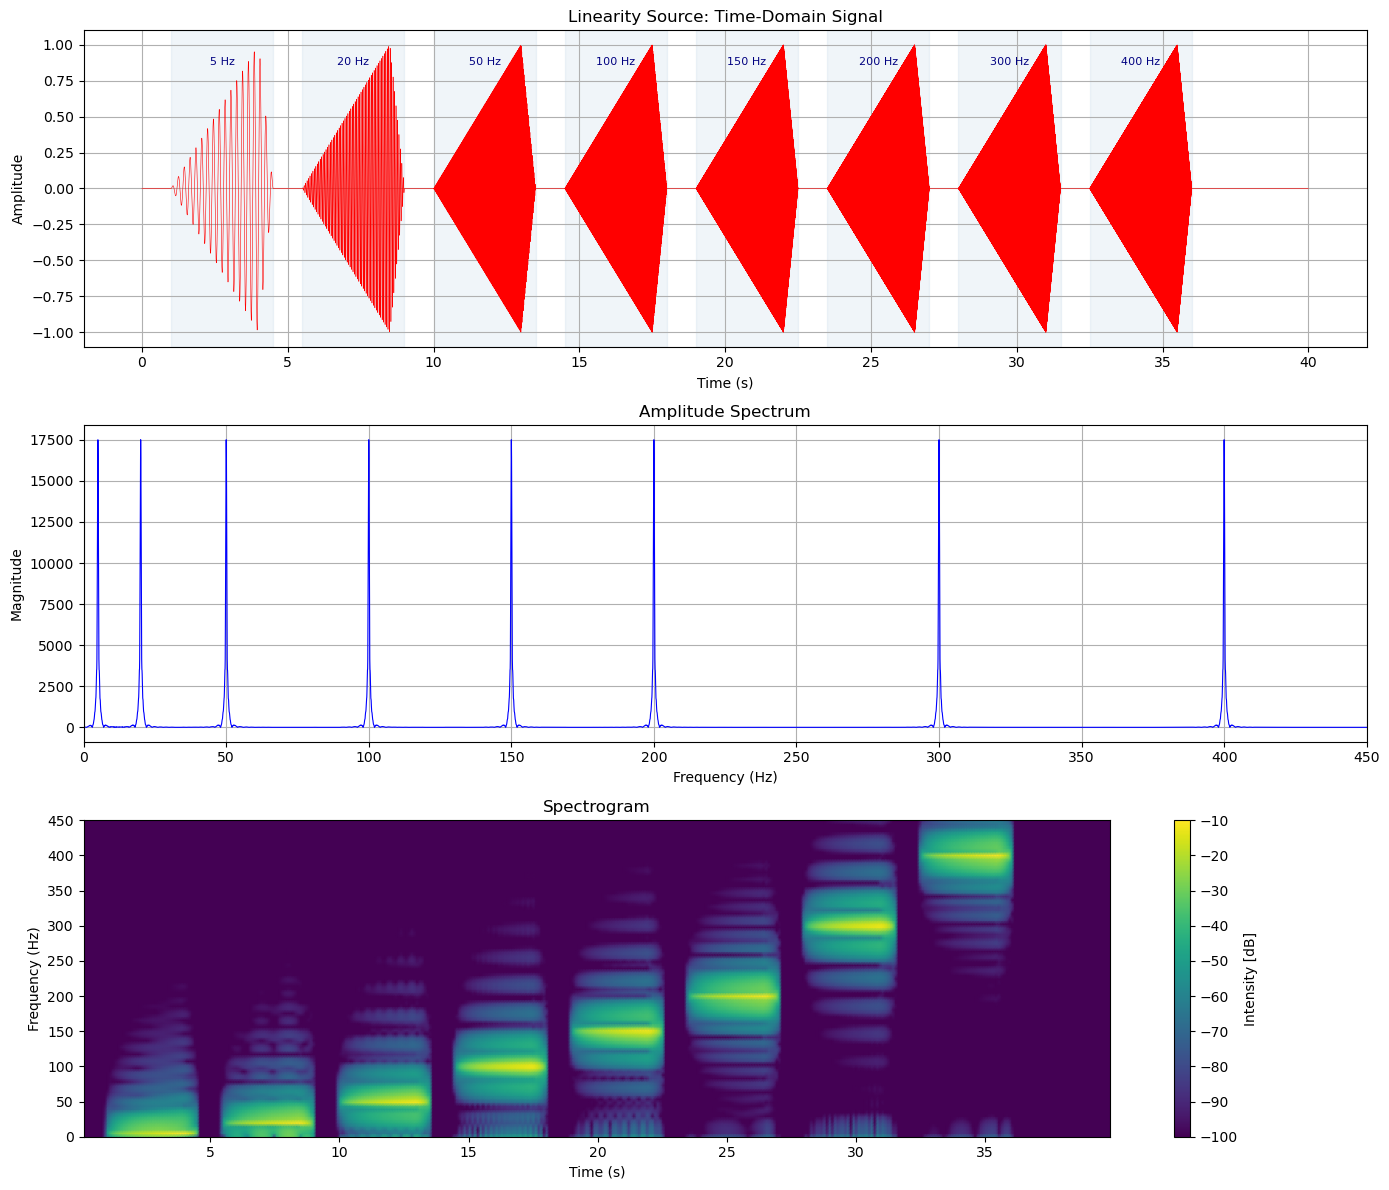

In [8]:
# ==========================================
# PLOT LINEARITY SIGNAL
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(14, 12))

# --- Time domain ---
axs[0].plot(t_lin, lin_signal, 'r', lw=0.4)
axs[0].set_title('Linearity Source: Time-Domain Signal')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Amplitude')
#axs[0].set_xlim(10, 15)
axs[0].grid(True)

# Shade and label each frequency segment
t_cursor = buffer_duration
for freq in frequencies:
    axs[0].axvspan(t_cursor, t_cursor + segment_duration, alpha=0.08, color='steelblue')
    axs[0].text(t_cursor + segment_duration / 2, 0.88, f'{freq} Hz',
                ha='center', va='center', fontsize=8, color='navy')
    t_cursor += segment_duration + buffer_duration

# --- Amplitude spectrum ---
yf_lin = rfft(lin_signal)
xf_lin = rfftfreq(len(lin_signal), 1 / fs_lin)
axs[1].plot(xf_lin, np.abs(yf_lin), 'b', lw=0.8)
axs[1].set_title('Amplitude Spectrum')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Magnitude')
axs[1].set_xlim(0, max(frequencies) + 50)
axs[1].grid(True)

# --- Spectrogram ---
f_spec, t_spec, Sxx = spectrogram(lin_signal, fs_lin, nperseg=4096, noverlap=2048)
im = axs[2].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12),
                        shading='gouraud', cmap='viridis', vmin=-100, vmax=-10)
axs[2].set_title('Spectrogram')
axs[2].set_ylabel('Frequency (Hz)')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylim(0, max(frequencies) + 50)
fig.colorbar(im, ax=axs[2], label='Intensity [dB]')

plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# EXPORT LINEARITY SIGNAL TO TXT
# ==========================================
freq_str = '-'.join(str(f) for f in frequencies)
lin_output_filename = f'LinearitySource_{freq_str}Hz_{len(lin_signal)}nt_fs{fs_lin}Hz.txt'

with open(lin_output_filename, 'w') as f:
    f.write('ArbWave= \n')
    for val in lin_signal:
        f.write(f'{val:.6f} \n')

print(f'Successfully saved to {lin_output_filename}')

Successfully saved to LinearitySource_5-20-50-100-150-200-300-400Hz_800000nt_fs20000Hz.txt
